In [1]:
import utils
import pandas as pd
import os
from pathlib import Path
from glob import glob
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# read the 5 cases that have analyzes for primary and recurrent
df = pd.read_excel("../data/drugs_for_each_case_in_one_sheet.xlsx")

my_list_1 = ["419b4c0a-c23f-4214-8de0-722d2ae0846b","0317a370-6a1e-44bd-bfd0-81fd06ec56fb"]
my_list_2 = [ "28f0c53a-abdd-4789-adcf-f59132ae3a92", "928160c7-f711-4b23-832c-8c12aea9fe85"]
my_list_3 = ["982e2940-10b0-4383-bde8-f7ccb9920fc4","ddd4c4a7-6057-4244-aa4d-ccffe6e1c95a"]
my_list_4 = ["90629e6e-2e1e-4f31-884a-6bca2c24ce11","fe179a60-5e81-48c1-b437-7c38ed910ba8"]
my_list_5 = [ "c904090b-149e-4146-9769-f0d2ff965da9","b4919075-90a9-4c8a-82a0-a0b5f9944ad3"]

case1 = df[df["Patient"].isin(my_list_1)]
case2 = df[df["Patient"].isin(my_list_2)]
case3 = df[df["Patient"].isin(my_list_3)]
case4 = df[df["Patient"].isin(my_list_4)]
case5 = df[df["Patient"].isin(my_list_5)]

In [3]:
# to compare cases on different aspects like control nodes, drugs, controlled proteins; returns what is in addition and what is common 
def compare_elements(df, column):
    dict_case={}
    grouped = (
        df.groupby("Patient")[column]
        .apply(lambda x: set(
            elem.strip()
            for row in x
            for elem in row.split(",")
        ))
    )

    type1, type2 = grouped.index
    
    dict_case[type1] = grouped[type1] - grouped[type2]     
    dict_case[type2] = grouped[type2] - grouped[type1]     
    dict_case["common"] = grouped[type1] & grouped[type2]
    
    return dict_case   


In [4]:
# function that accesses the previous function, print the results and save the controlled proteins for each case (one for each sample and one for the common part)
def results_of_comparison(case,name):

    print(name)
    result_control = compare_elements(case, "Control nodes")
    for i in result_control:
        print("Control nodes",i,len(result_control[i]))

    result_drug = compare_elements(case, "Drug")
    for i in result_drug:
        print("Drugs",i, len(result_drug[i]))

    result_proteins = compare_elements(case, "Patient proteins")
    for i in result_proteins:
        print("Controlled proteins",i,len(result_proteins[i]))
        with open("../data/progression/"+name+"_"+i+".txt","w") as f:
            for item in result_proteins[i]:
                f.write(f"{item}\n")
    return result_proteins

c1=results_of_comparison(case1,"case1")
c2=results_of_comparison(case2,"case2")
c3=results_of_comparison(case3,"case3")
c4=results_of_comparison(case4,"case4")
c5=results_of_comparison(case5,"case5")

case1
Control nodes 0317a370-6a1e-44bd-bfd0-81fd06ec56fb 19
Control nodes 419b4c0a-c23f-4214-8de0-722d2ae0846b 16
Control nodes common 45
Drugs 0317a370-6a1e-44bd-bfd0-81fd06ec56fb 29
Drugs 419b4c0a-c23f-4214-8de0-722d2ae0846b 26
Drugs common 115
Controlled proteins 0317a370-6a1e-44bd-bfd0-81fd06ec56fb 46
Controlled proteins 419b4c0a-c23f-4214-8de0-722d2ae0846b 47
Controlled proteins common 164
case2
Control nodes 28f0c53a-abdd-4789-adcf-f59132ae3a92 11
Control nodes 928160c7-f711-4b23-832c-8c12aea9fe85 18
Control nodes common 42
Drugs 28f0c53a-abdd-4789-adcf-f59132ae3a92 23
Drugs 928160c7-f711-4b23-832c-8c12aea9fe85 9
Drugs common 120
Controlled proteins 28f0c53a-abdd-4789-adcf-f59132ae3a92 39
Controlled proteins 928160c7-f711-4b23-832c-8c12aea9fe85 52
Controlled proteins common 141
case3
Control nodes 982e2940-10b0-4383-bde8-f7ccb9920fc4 9
Control nodes ddd4c4a7-6057-4244-aa4d-ccffe6e1c95a 19
Control nodes common 44
Drugs 982e2940-10b0-4383-bde8-f7ccb9920fc4 26
Drugs ddd4c4a7-6057-42

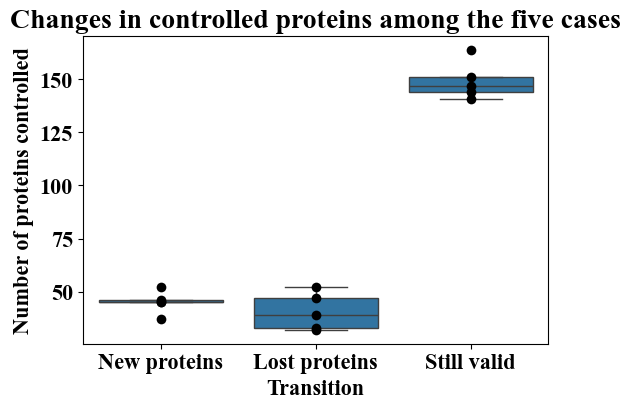

In [5]:
# plot the transitions of the number of controlled proteins between primary and recurrent tumors
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 16
plt.rcParams['font.weight'] = 'bold'

cases = [c1, c2, c3, c4, c5]
case_names = ['Case1','Case2','Case3','Case4','Case5']
my_list=[my_list_1, my_list_2, my_list_3, my_list_4, my_list_5]

all_counts = []

for case_name, case, val in zip(case_names, cases, my_list):
    all_counts.append({'Case': case_name, 'Transition': 'New proteins', 'Count': len(case[val[1]])})
    all_counts.append({'Case': case_name, 'Transition': 'Lost proteins', 'Count': len(case[val[0]])})
    all_counts.append({'Case': case_name, 'Transition': 'Still valid', 'Count': len(case['common'])})
    
counts_df = pd.DataFrame(all_counts)

plt.figure(figsize=(6,4))
sns.boxplot(x='Transition', y='Count', data=counts_df,showfliers=False)
sns.stripplot(x='Transition', y='Count', data=counts_df, color='black', size=7, jitter=0, alpha=1)
plt.title("Changes in controlled proteins among the five cases",fontsize=20, fontfamily='Times New Roman', fontweight='bold')
plt.xlabel('Transition', fontsize=16, fontweight='bold')
plt.ylabel("Number of proteins controlled",fontsize=16, fontfamily='Times New Roman', fontweight='bold')

save_path = Path("../data/fig_res")
save_path.mkdir(parents=True, exist_ok=True)

plt.savefig(str(save_path)+"/transition.eps", format="eps", dpi=500, bbox_inches='tight')
plt.show()


In [6]:
folder_path = "../data/progression"

data_dict = {}

for filename in os.listdir(folder_path):
    if filename.endswith(".txt"):
        file_path = os.path.join(folder_path, filename)
        name_without_ext = os.path.splitext(filename)[0]
        
        with open(file_path, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f.readlines()]
            data_dict[name_without_ext] = lines

In [7]:
path_rez = "../data/reactome_progression"
path_set = Path(path_rez)
path_set.mkdir(exist_ok=True)
os.chdir(path_rez)

for filename in data_dict:
    utils.enrichent_results(data_dict[filename], filename, 'Reactome_Pathways_2024')

In [8]:
#read the obtained files into a df and filter to remain only with FDR < 0.05
os.chdir("..")
folder = "./reactome_progression"
files = glob(f"{folder}/*.txt")

df = pd.concat(
    [pd.read_csv(f, sep="\t").assign(filename=os.path.basename(f))
     for f in files],
    ignore_index=True
)

df = df[df["Adjusted P-value"] <0.05]
df.loc[:, 'group_start'] = df['filename'].str.split('_').str[0]

In [9]:
# see for each sample of each case which pathways are unique/common to each of them and the number of unique/common pathways
def unique_values_per_subgroup(group_df, col='Term'):

    results = {}
    subgroups = group_df['filename'].unique()
    
    for sub in subgroups:
        vals_sub = set(group_df.loc[group_df['filename']==sub, col])
        vals_others = set(group_df.loc[group_df['filename']!=sub, col])
        results[sub] = vals_sub - vals_others
    return results

grouped = df.groupby('group_start')

unique_dict = {}

for start, group in grouped:
    unique_dict[start] = unique_values_per_subgroup(group)

count_unique = {start: {sub: len(vals) for sub, vals in subs.items()} 
                for start, subs in unique_dict.items()}

count_unique

{'case1': {'case1_0317a370-6a1e-44bd-bfd0-81fd06ec56fb.txt': 8,
  'case1_419b4c0a-c23f-4214-8de0-722d2ae0846b.txt': 80,
  'case1_common.txt': 231},
 'case2': {'case2_28f0c53a-abdd-4789-adcf-f59132ae3a92.txt': 27,
  'case2_928160c7-f711-4b23-832c-8c12aea9fe85.txt': 45,
  'case2_common.txt': 226},
 'case3': {'case3_982e2940-10b0-4383-bde8-f7ccb9920fc4.txt': 50,
  'case3_common.txt': 150,
  'case3_ddd4c4a7-6057-4244-aa4d-ccffe6e1c95a.txt': 56},
 'case4': {'case4_90629e6e-2e1e-4f31-884a-6bca2c24ce11.txt': 82,
  'case4_common.txt': 218,
  'case4_fe179a60-5e81-48c1-b437-7c38ed910ba8.txt': 11},
 'case5': {'case5_b4919075-90a9-4c8a-82a0-a0b5f9944ad3.txt': 35,
  'case5_c904090b-149e-4146-9769-f0d2ff965da9.txt': 13,
  'case5_common.txt': 186}}